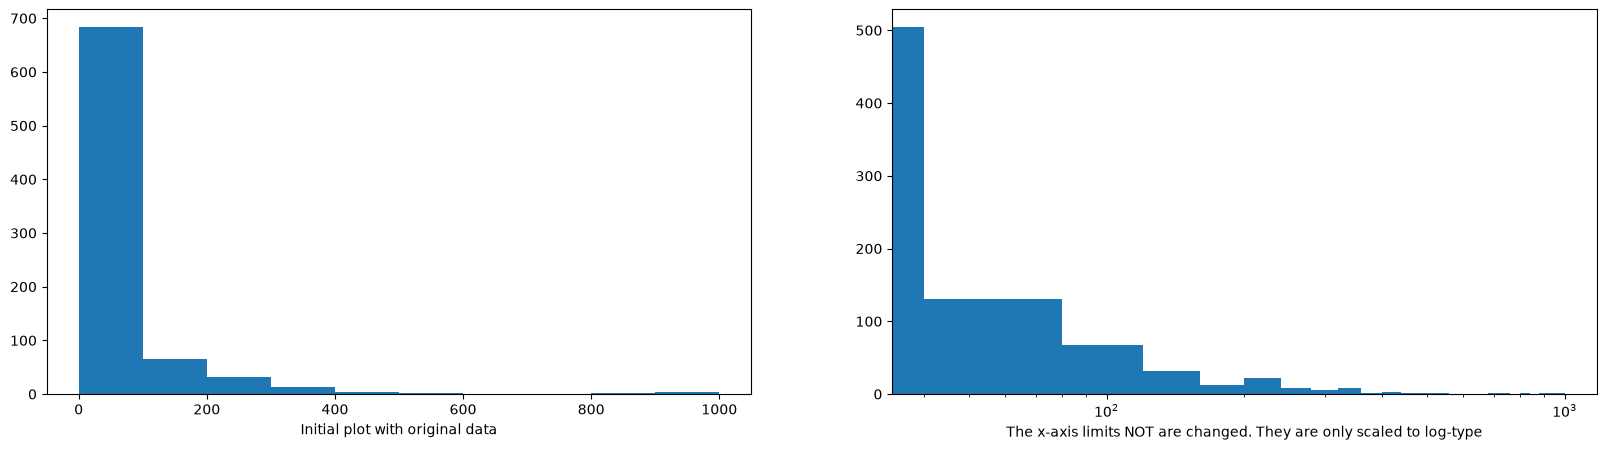

In [2]:
## Necessary import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
%matplotlib inline

pokemon = pd.read_csv('pokemon.csv')
pokemon.head(10)

plt.figure(figsize = [20, 5])

## HISTOGRAM ON LEFT: full data without scaling
plt.subplot(1, 2, 1)
plt.hist(data=pokemon, x='weight');
## Display a label on the x-axis
plt.xlabel('Initial plot with original data')


## HISTOGRAM ON RIGHT 
plt.subplot(1, 2, 2)

## Get the ticks for bins between [0 - maximum weight]
bins = np.arange(0, pokemon['weight'].max() + 40, 40)
plt.hist(data=pokemon, x='weight', bins=bins);

## The argument in the xscale() represents the axis scale type to apply.
## The possible values are: {"linear", "log", "symlog", "logit", ...}
## Refer - https://matplotlib.org/3.1.1/api/_as_gen/matplotlib.pyplot.xscale.html
plt.xscale('log')
plt.xlabel('The x-axis limits NOT are changed. They are only scaled to log-type')
plt.show()

In [3]:
## Describe the data
pokemon['weight'].describe()

count    807.000000
mean      61.771128
std      111.519355
min        0.100000
25%        9.000000
50%       27.000000
75%       63.000000
max      999.900000
Name: weight, dtype: float64

In [4]:
## Transform the describe() to a scale of log10
## Documentation: [numpy `log10`](https://docs.scipy.org/doc/numpy/reference/generated/numpy.log10.html)
np.log10(pokemon['weight'].describe())

count    2.906874
mean     1.790786
std      2.047350
min     -1.000000
25%      0.954243
50%      1.431364
75%      1.799341
max      2.999957
Name: weight, dtype: float64

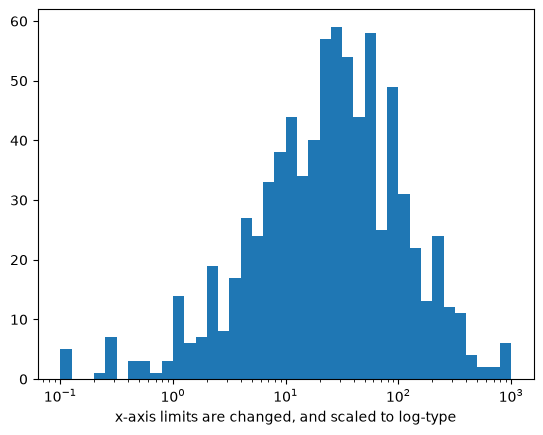

In [5]:
## Axis transformation
## Bin size
bins = 10 ** np.arange(-1, 3 + 0.1, 0.1)
plt.hist(data=pokemon, x='weight', bins=bins);

## The argument in the xscale() represents the axis scale type to apply.
## The possible values are: {"linear", "log", "symlog", "logit", ...}
plt.xscale('log')

## Apply x-axis label
## Documentatin: [matplotlib `xlabel`](https://matplotlib.org/api/_as_gen/matplotlib.pyplot.xlabel.html))
plt.xlabel('x-axis limits are changed, and scaled to log-type')
plt.show()

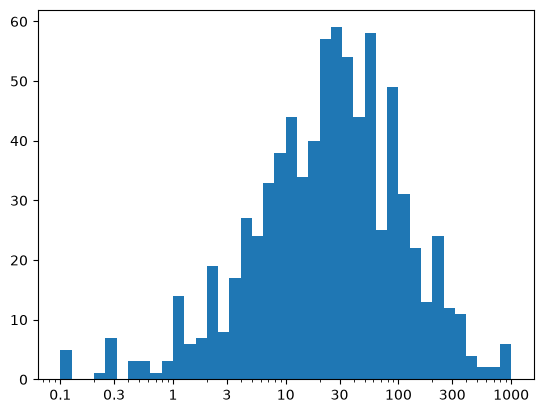

In [6]:
## Get the ticks for bins between [0 - maximum weight]
bins = 10 ** np.arange(-1, 3 + 0.1, 0.1)

## Generate the x-ticks you want to apply
ticks = [0.1, 0.3, 1, 3, 10, 30, 100, 300, 1000]
## Convert ticks into string values, to be displaye dlong the x-axis
labels = ['{}'.format(v) for v in ticks]

## Plot the histogram
plt.hist(data=pokemon, x='weight', bins=bins);

## The argument in the xscale() represents the axis scale type to apply.
## The possible values are: {"linear", "log", "symlog", "logit", ...}
plt.xscale('log')

## Apply x-ticks
plt.xticks(ticks, labels);
plt.show()

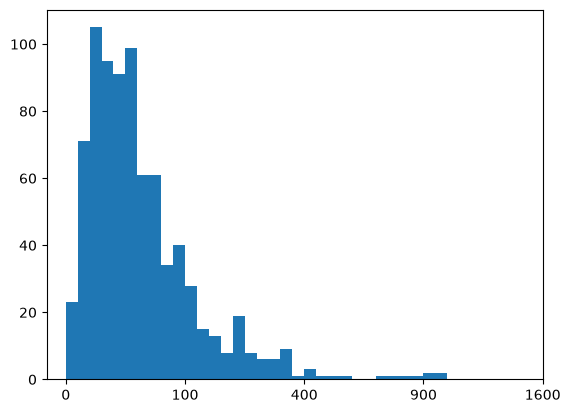

In [7]:
def sqrt_trans(x, inverse=False):
    """transformation helper function"""
    if not inverse:
        return np.sqrt(x)
    else:
        return x**2

## Bin resizing, to transform the x-axis    
bin_edges = np.arange(0, sqrt_trans(pokemon['weight'].max()) + 1, 1)

## Plot the scaled data
plt.hist(pokemon['weight'].apply(sqrt_trans), bins=bin_edges)

## Identify the tick-locations
tick_locs = np.arange(0, sqrt_trans(pokemon['weight'].max()) + 10, 10)

## Apply x-ticks
plt.xticks(tick_locs, sqrt_trans(tick_locs, inverse=True).astype(int));
plt.show()

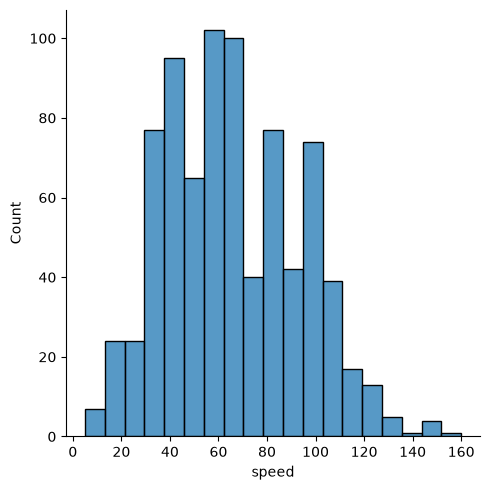

In [8]:
# The pokemon dataset is available to download at the bottom of this page.
# The kind argument can take any one value from {“hist”, “kde”, “ecdf”}.
sb.displot(pokemon['speed'], kind='hist');
# Use the 'kde' kind for kernel density estimation
# sb.displot(pokemon['speed'], kind='kde');

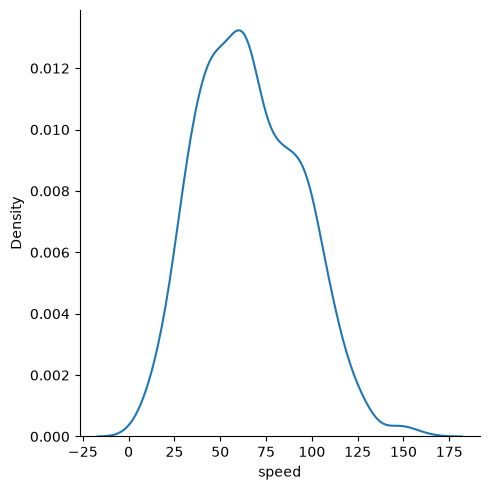

In [9]:
sb.displot(pokemon['speed'], kind='kde');

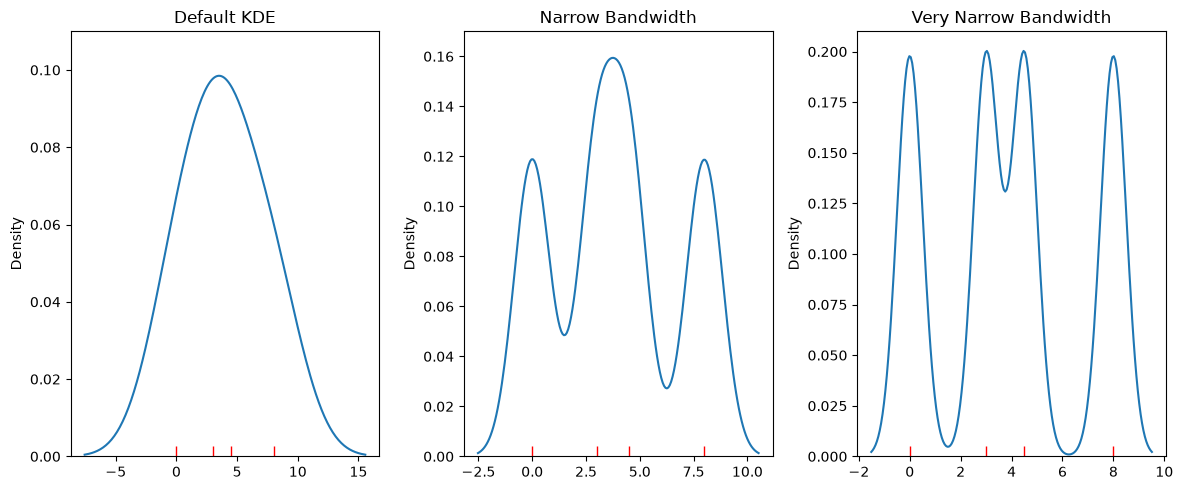

In [10]:
data = [0.0, 3.0, 4.5, 8.0]
plt.figure(figsize=[12, 5])

# Left plot: Showing kde lumps with the default settings
plt.subplot(1, 3, 1)
sb.rugplot(data, color='r')
sb.kdeplot(data)
plt.ylim(0, 0.11)
plt.title("Default KDE")

# Central plot: KDE with narrow bandwidth to show individual probability lumps
plt.subplot(1, 3, 2)
sb.rugplot(data, color='r')
sb.kdeplot(data, bw_adjust=1/3)
plt.ylim(0, 0.17)
plt.title("Narrow Bandwidth")

# Right plot: Choosing a different, triangular kernel function (lump shape)
plt.subplot(1, 3, 3)
sb.rugplot(data, color='r')
sb.kdeplot(data, bw_adjust=1/5)  # Removed kernel parameter
plt.ylim(0, 0.21)
plt.title("Very Narrow Bandwidth")

# Adjust subplot layout to prevent overlap
plt.tight_layout()

plt.show()